# 06 — KNN Interpretability with LIME
KNN has no internal parameters to inspect. We use LIME to explain individual predictions by fitting a local linear approximation around each instance.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd

from src.data import load_data, split_data
from src.models import train_knn
from src.interpret_knn import explain_instance, plot_explanation
from IPython.display import Image

In [2]:
X, y = load_data('../data/heart_failure_clinical_records_dataset.csv')
X_train, X_test, y_train, y_test = split_data(X, y)

pipeline = train_knn(X_train, y_train)

FEATURE_NAMES = list(X.columns)
CLASS_NAMES = ['survived', 'deceased']

## Selecting Representative Instances
We pick three patients from the test set:
- **Instance A** — predicted survived with high confidence
- **Instance B** — predicted deceased with high confidence
- **Instance C** — borderline case (predicted probabilities close to 0.5)

In [3]:
proba = pipeline.predict_proba(X_test)
prob_survived = proba[:, 0]
prob_deceased = proba[:, 1]

# Most confident survived prediction
idx_survived = prob_survived.argmax()

# Most confident deceased prediction
idx_deceased = prob_deceased.argmax()

# Most borderline: closest probability to 0.5
idx_borderline = (abs(prob_survived - 0.5)).argmin()

print(f'Instance A (survived):   index={idx_survived}, P(survived)={prob_survived[idx_survived]:.2f}')
print(f'Instance B (deceased):   index={idx_deceased}, P(deceased)={prob_deceased[idx_deceased]:.2f}')
print(f'Instance C (borderline): index={idx_borderline}, P(survived)={prob_survived[idx_borderline]:.2f}')

Instance A (survived):   index=2, P(survived)=1.00
Instance B (deceased):   index=35, P(deceased)=0.71
Instance C (borderline): index=0, P(survived)=0.57


In [4]:
# Show the raw feature values for each selected instance
selected = X_test.iloc[[idx_survived, idx_deceased, idx_borderline]].copy()
selected.index = ['A (survived)', 'B (deceased)', 'C (borderline)']
selected

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking
A (survived),60.0,1,737,0,60,1,210000.0,1.5,135,1,1
B (deceased),45.0,0,582,0,14,0,166000.0,0.8,127,1,0
C (borderline),60.0,1,257,1,30,0,150000.0,1.0,137,1,1


## Instance A — Confident Survived Prediction
LIME perturbs the feature values around this patient and fits a local linear model to approximate the KNN decision boundary.

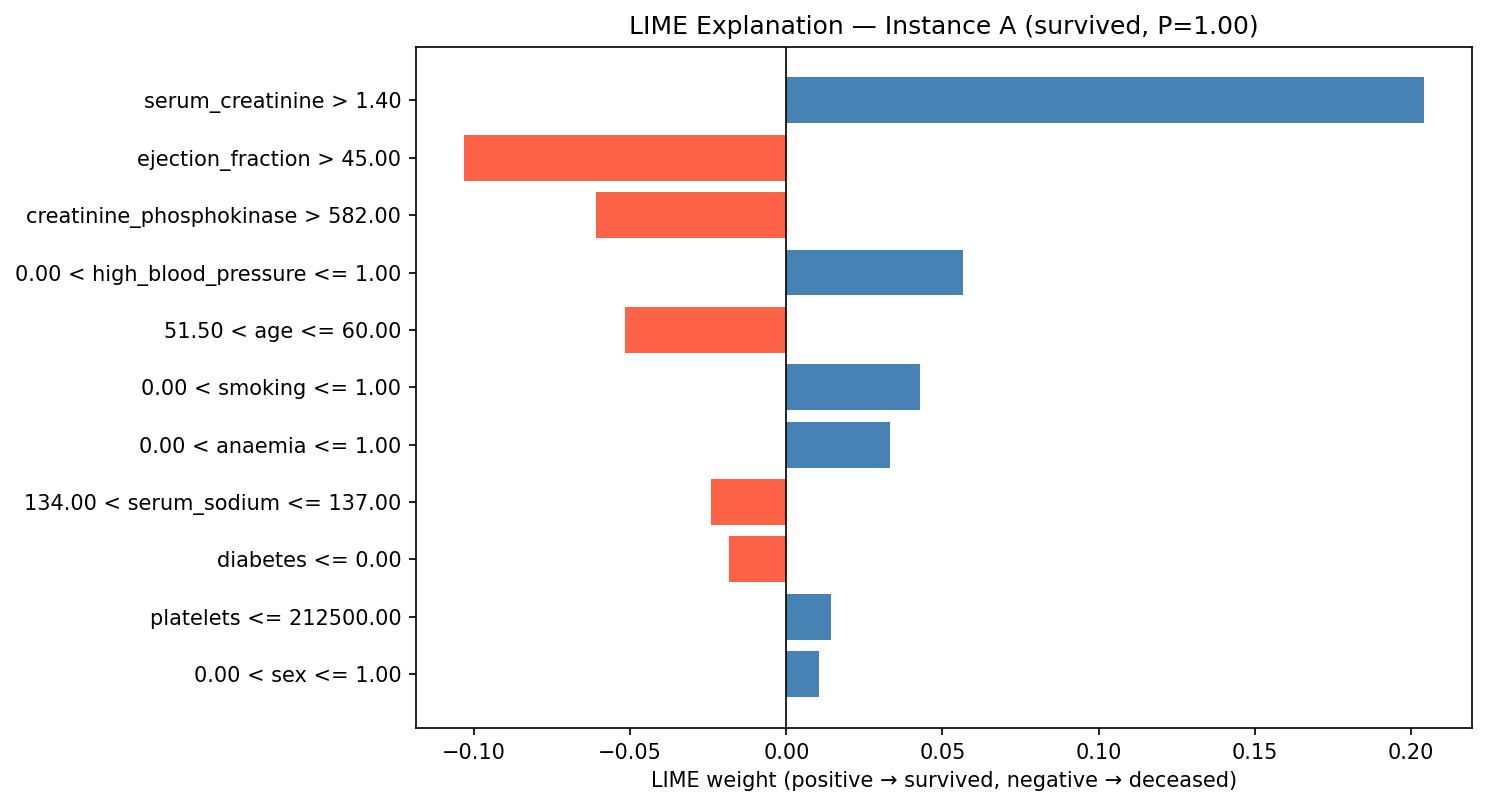

In [5]:
_, exp_a = explain_instance(
    pipeline, X_train, X_test.iloc[idx_survived], FEATURE_NAMES, CLASS_NAMES
)
plot_explanation(exp_a, instance_idx=f'A (survived, P={prob_survived[idx_survived]:.2f})', path='../outputs/lime_instance_a.png')
Image('../outputs/lime_instance_a.png')

## Instance B — Confident Deceased Prediction

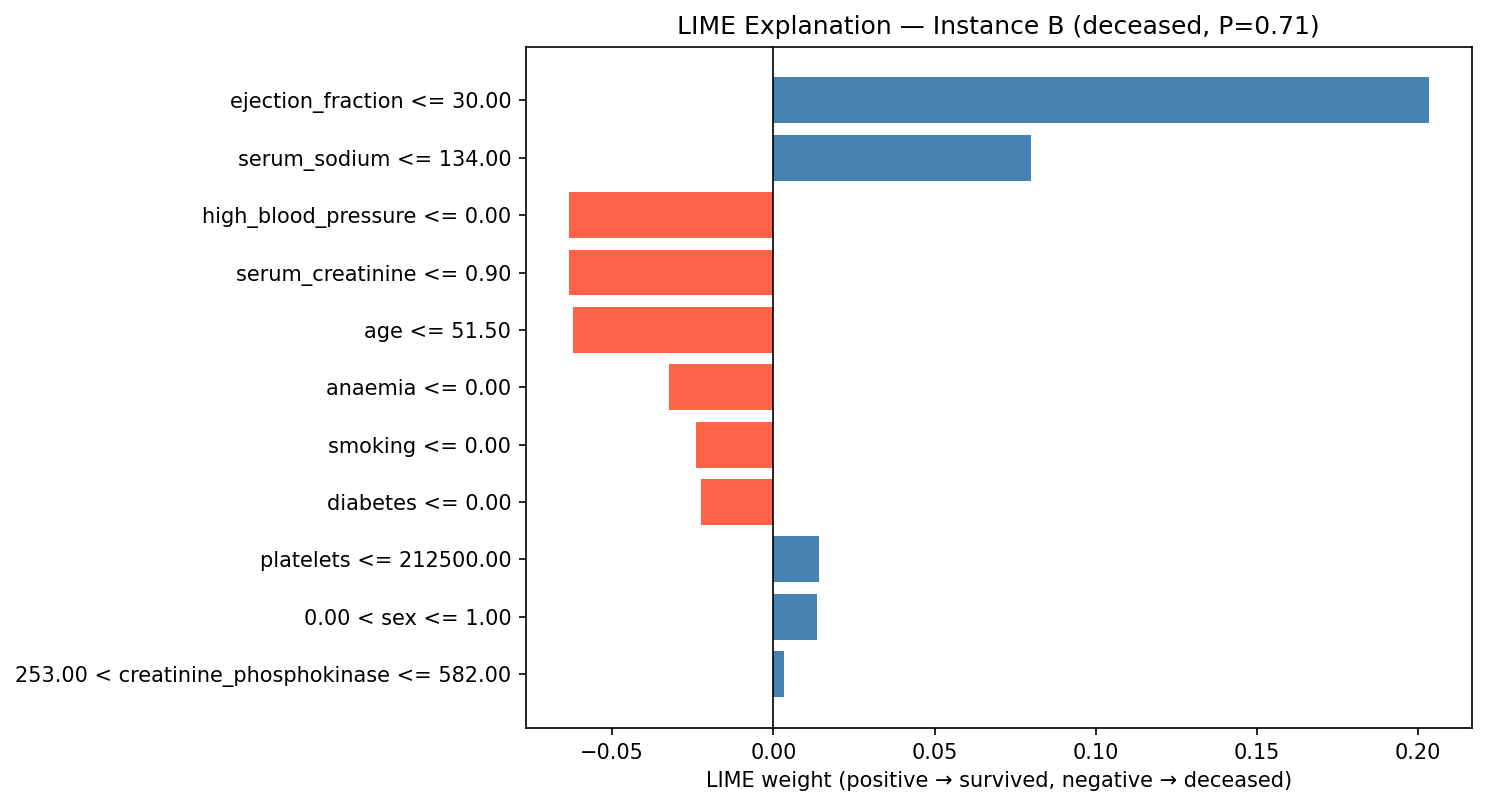

In [6]:
_, exp_b = explain_instance(
    pipeline, X_train, X_test.iloc[idx_deceased], FEATURE_NAMES, CLASS_NAMES
)
plot_explanation(exp_b, instance_idx=f'B (deceased, P={prob_deceased[idx_deceased]:.2f})', path='../outputs/lime_instance_b.png')
Image('../outputs/lime_instance_b.png')

## Instance C — Borderline Case

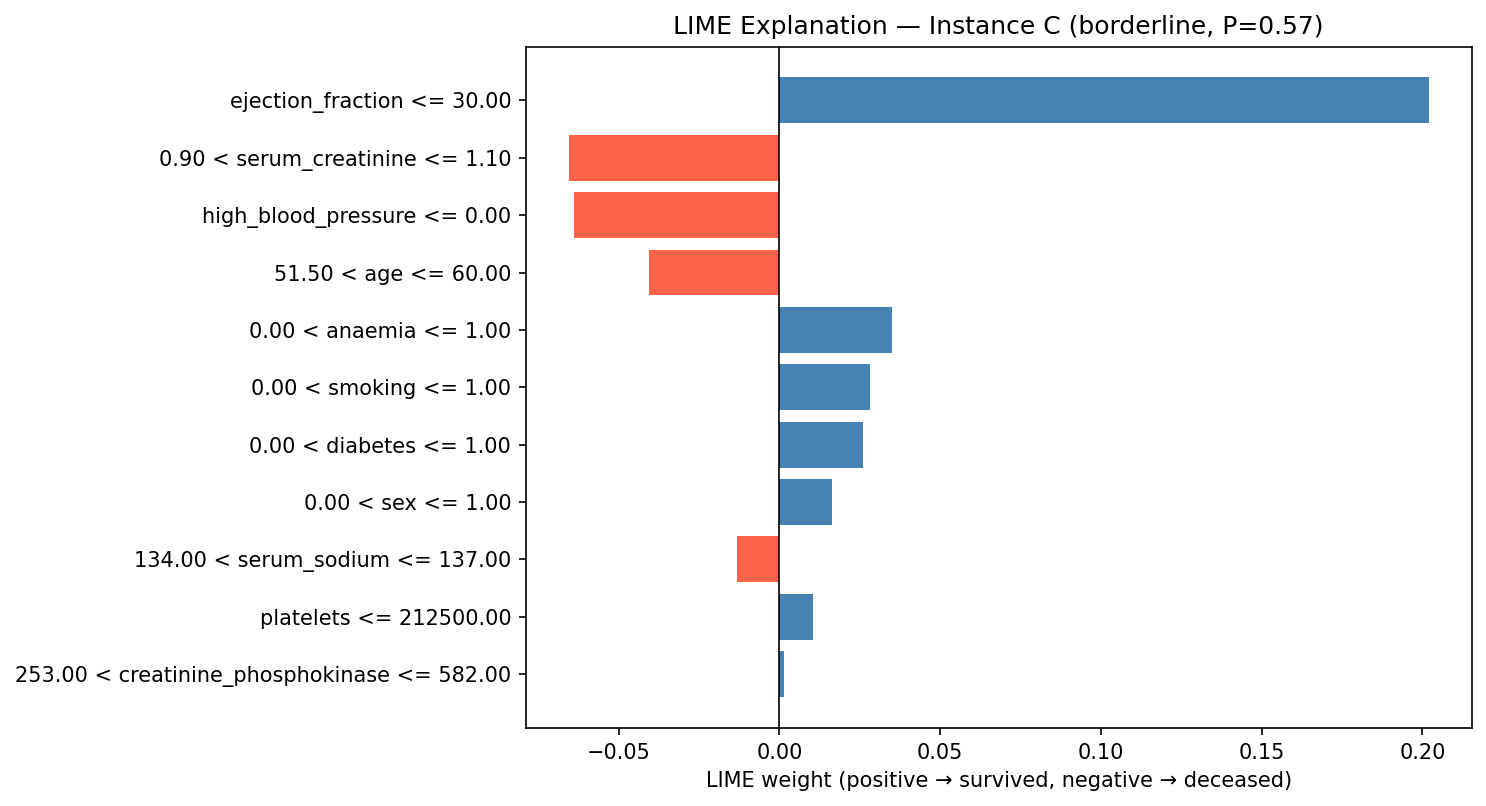

In [7]:
_, exp_c = explain_instance(
    pipeline, X_train, X_test.iloc[idx_borderline], FEATURE_NAMES, CLASS_NAMES
)
plot_explanation(exp_c, instance_idx=f'C (borderline, P={prob_survived[idx_borderline]:.2f})', path='../outputs/lime_instance_c.png')
Image('../outputs/lime_instance_c.png')

## Observations

### How to read LIME charts
- Each bar represents one feature's local contribution to the prediction
- **Blue (positive weight)** → pushes toward class 0 (survived)
- **Red (negative weight)** → pushes toward class 1 (deceased)
- Bar length = magnitude of influence for this specific patient
- LIME is **local** — the weights are only valid near this instance, not globally

### What KNN is doing
KNN predicts by majority vote among the 7 nearest neighbours in scaled feature space. LIME approximates which features placed this patient close to its neighbours. A feature with a large LIME weight means that feature strongly determined which neighbours were "nearest".

### Comparison with Decision Tree and Naive Bayes
- The Decision Tree uses the same 2–3 features for every prediction (global rules)
- Naive Bayes weighs all features simultaneously for every prediction (global distributions)
- KNN explanations vary per instance — the influential features for patient A may differ entirely from patient B, because different regions of feature space have different nearest-neighbour structures